# 01 - Data Space

## What evidence did we actually collect?

Notebook 00 introduced the workshop frame:

$$
\mathcal{H}+\boxed{\mathcal{D}}+\mathcal{O}\rightarrow s.
$$

This notebook slows down at $\mathcal{D}$: the finite evidence the learner actually receives. Before choosing a hypothesis space or objective, we need to ask what structure we gave the dataset and what that structure assumes.

For the running problem, we choose supervised pairs $(x_i,y_i)$. That choice says we are trying to learn a function from inputs to a predicted response. The rest of the notebook asks what those paired observations reveal about noise, coverage, geometry, sampling design, and what remains underdetermined.

## Learning objectives

By the end of this notebook, you should be able to:

1. distinguish the observed dataset $\mathcal{D}$ from the hidden data-generating process;
2. explain how representation, noise, coverage, data-space geometry, and sampling design affect what the learner can infer;
3. identify weakly supported regions in a simple dataset;
4. explain why data alone usually leaves several explanations possible;
5. diagnose whether a modelling issue is currently driven by $\mathcal{D}$, $\mathcal{H}$, or $\mathcal{O}$.

## Session arc

This notebook follows one semantic wave:

1. **Abstract:** the learner only receives finite evidence $\mathcal{D}$, not the hidden world directly.
2. **Concrete:** generate noisy observations from one hidden response rule.
3. **Inspect:** vary noise, sample location, coverage, data-space geometry, and repeated measurement.
4. **Diagnose:** identify what the data strongly constrain and what they leave open.
5. **Repack:** later choices about $\mathcal{H}$ and $\mathcal{O}$ must add assumptions where $\mathcal{D}$ is insufficient.

Use this question throughout:

> **What changed, what stayed fixed, and which lever is active: $\mathcal{D}$, $\mathcal{H}$, or $\mathcal{O}$?**

In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


## Dataset Structure and Assumptions

For this problem, we choose to record the dataset as input-output pairs:

$$
(x_i, y_i) \in \mathcal{X} \times \mathcal{Y}.
$$

The dataset is the finite set of those pairs:

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}, \qquad x_i\in\mathcal{X}, \quad y_i\in\mathcal{Y}.
$$

This is not just notation. Writing rows as $(x_i,y_i)$ says we are treating the problem as prediction or explanation of $y$ from $x$. It decides what counts as an input condition, what counts as the response, which variables are ignored, and what kind of function later notebooks will try to learn:

$$
h: \mathcal{X} \rightarrow \mathcal{Y}.
$$

Equivalently, the dataset is a finite sample from a data-generating process:

$$
(x_i,y_i) \sim P_{\mathrm{data}}, \qquad \mathcal{D}_n=\{(x_i,y_i)\}_{i=1}^{n}.
$$

This is the first data-space choice: representation. The learner sees $\mathcal{D}_n$, not $P_{\mathrm{data}}$ and not the underlying world directly. So the data-space question is: what does this finite paired sample support, and where does it leave room for multiple explanations?

> **Discuss.** What is one assumption introduced by writing your problem as inputs $x$ and outputs $y$? What would change if you chose a different response, different inputs, or a different unit of observation?


## A Small Observation World

For the data-space lesson we will use a deliberately simple simulated world. Imagine observing a response $y$ that changes smoothly with one input $x$. The input could be time after treatment, concentration, temperature, simulation setting, or distance from a sensor. The response could be growth, signal intensity, failure probability, measured energy, or annotation score.

The hidden signal in this teaching example is

$$
f^*: \mathcal{X} \rightarrow \mathcal{Y}, \qquad f^*(x)=\sin(2\pi x), \qquad \mathcal{Y}=\mathbb{R}.
$$

An observation does not hand us the hidden signal directly. It gives a recorded value near that signal:

$$
y_i = f^*(x_i)+\epsilon_i.
$$

The term $\epsilon_i$ stands for whatever makes observations vary around the signal: measurement error, biological variation, sensor noise, annotation disagreement, simulation stochasticity, or unrecorded context.

In the notebook, the dataset is stored as two aligned arrays: `x_observed` for the input locations and `y_observed` for the recorded responses. The $i$th entry of each array forms one row of evidence, $(x_i, y_i)$. That storage choice is simple, but it already frames the world as input-output pairs: later notebooks will ask which functions can map the observed inputs to plausible responses.

This is the second data-space diagnostic: noise. The next cell creates a finite dataset and prints a few simple quantities from it. Edit the variables and rerun the next two cells. Try a small sample, a noisier observation process, or a different sampling pattern, then ask what you could reasonably defend from these observations alone.

> **Try these three runs.** First use low noise with `sampling = "uniform"`, then high noise with `sampling = "uniform"`, then `sampling = "partial_domain"`. Before each run, predict whether the main limitation will come from observation noise or from missing coverage.

The hidden curve is available only because this is a simulation. Start with it hidden in the plot if you want the learner's view; reveal it only when you want to calibrate your intuition against the toy world's answer key.


### Before running: predict what the evidence will show

The next cell creates one finite noisy dataset. The hidden response rule is visible only because this is a simulation, so first read the settings as data-space choices.

Before running, write a prediction for each setting:

| Setting | What should become easier or harder to infer? |
|---|---|
| More samples | |
| More noise | |
| Clustered sampling | |
| Partial-domain sampling | |


In [2]:
# Data-space controls. Edit these values and rerun the section.
n_samples = 20
noise_std = 1.00  # Start noisy enough that the pattern is not immediately obvious.
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"
show_hidden_function = False  # Change to True to reveal the simulation's hidden curve.

x_observed, y_observed = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)

true_at_observed = data.true_function(x_observed)
observation_error = y_observed - true_at_observed
x_gaps = np.diff(np.r_[0.0, x_observed, 1.0])

observable_summary = [
    {
        "n": len(x_observed),
        "x_min": np.min(x_observed),
        "x_max": np.max(x_observed),
        "largest_x_gap": np.max(x_gaps),
        "y_mean": np.mean(y_observed),
        "y_std": np.std(y_observed),
    }
]
print_rows(observable_summary, title="What the learner can read from D")

preview_rows = []
for x, y in zip(x_observed[:8], y_observed[:8]):
    preview_rows.append({"x": x, "observed_y": y})

print()
print_rows(preview_rows, title="First eight rows of D")

simulation_check = [
    {
        "mean_observation_error": np.mean(observation_error),
        "sd_observation_error": np.std(observation_error),
    }
]
print()
print_rows(simulation_check, title="Simulation-only noise check")


What the learner can read from D
01. n=20, x_min=0.1774, x_max=0.9670, largest_x_gap=0.1774, y_mean=0.2638, y_std=1.1539

First eight rows of D
01. x=0.1774, observed_y=0.4203
02. x=0.1789, observed_y=1.5586
03. x=0.2263, observed_y=0.7567
04. x=0.2779, observed_y=0.8359
05. x=0.2983, observed_y=1.5961
06. x=0.3388, observed_y=2.6729
07. x=0.3549, observed_y=0.0773
08. x=0.3705, observed_y=2.0750

Simulation-only noise check
01. mean_observation_error=0.2102, sd_observation_error=0.8776


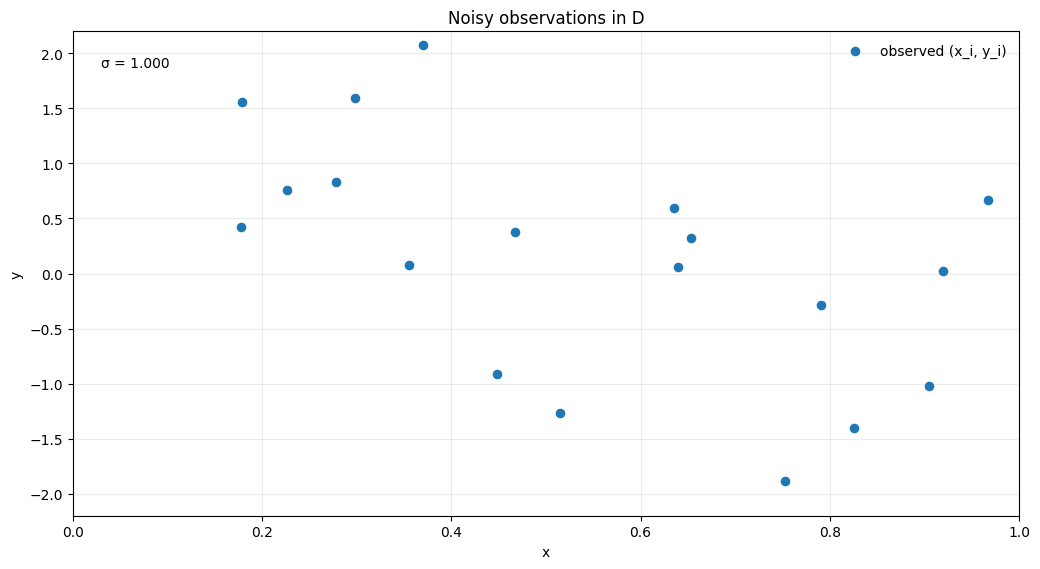

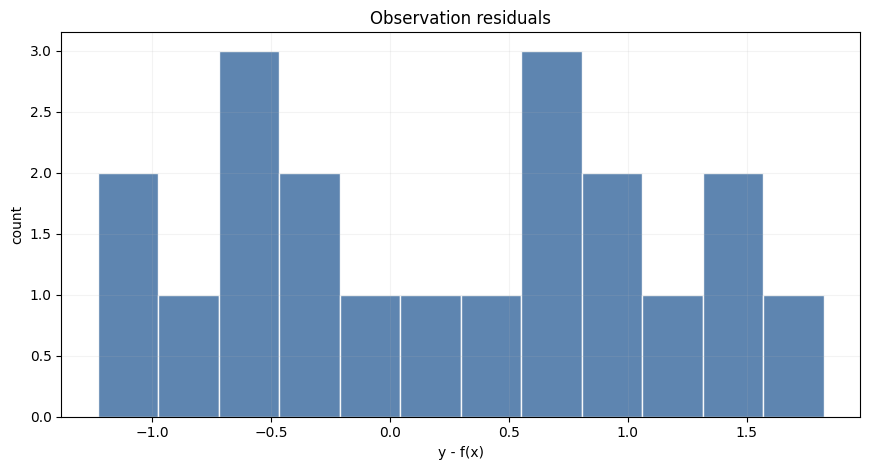

In [3]:
# Visualise the same evidence.
fig = plots.plot_measurement_world(x_observed, y_observed, noise_std=noise_std)
fig.axes[0].set_ylim(-2.2, 2.2)

if not show_hidden_function:
    hidden_line = fig.axes[0].lines[0]
    hidden_line.set_visible(False)
    fig.axes[0].set_title("Noisy observations in D")
    handles, labels = fig.axes[0].get_legend_handles_labels()
    visible = [
        (handle, label)
        for handle, label in zip(handles, labels)
        if label != "true f(x)"
    ]
    if visible:
        handles, labels = zip(*visible)
        fig.axes[0].legend(handles, labels, loc="upper right", frameon=False)

show_fig(fig)

residual_fig = plots.plot_residual_histogram(x_observed, y_observed)
show_fig(residual_fig)


### After running: read the data as evidence

Inspect the plot before thinking about models.

- Where are observations dense?
- Where are they sparse or missing?
- Does the visible pattern come from $\mathcal{D}$, or from the hidden curve that only the simulation reveals?
- If the hidden curve were removed, what claims would still be defensible?

**Repack.** The dataset is not the world. It is a finite, noisy, unevenly placed sample that will later constrain the hypotheses we can defend.

## Coverage, Gaps, and Sampling

The hidden rule in this toy world is low-dimensional. If we could see every possible noiseless pair $(x,f^*(x))$, those pairs would trace a one-dimensional curve inside the data space $\mathcal{X}\times\mathcal{Y}$.

Our finite observations only resolve that curve unevenly. Some parts of the input space may have many nearby samples. Other parts may be represented by a single noisy point, or by no point at all. This is the path from manifold intuition to coverage: the sample tells us which parts of the data-space geometry are well resolved and which parts remain weakly constrained.

This is the third data-space diagnostic: coverage. Predictions in well-covered regions are constrained by nearby observations. Predictions in gaps, near boundaries, or outside the sampled domain depend more strongly on assumptions we have not yet named.

Before running the comparison, predict which sampling case will have the largest unsupported interval in $x$ and which case would make right-hand-side prediction least defensible.

As you compare the panels below, look for places where the dataset gives strong local evidence and places where several different explanations would still be plausible. The shaded band marks the largest one-dimensional $x$ gap in each panel.

> **Discuss.** In your own data, how would you know whether coverage is good enough? For a high-dimensional input space, what proxy would you inspect: nearest neighbours, subgroups, geography, time, experimental settings, embedding plots, or performance by slice?


### Before running: predict coverage failures

The next comparison keeps the hidden response rule, sample size, and noise level fixed while changing where observations land. That makes this a data-space intervention.

Fill this table before running:

| Sampling case | Expected strength | Expected weakness | Likely risk |
|---|---|---|---|
| Uniform | | | |
| Clustered | | | |
| Partial domain | | | |


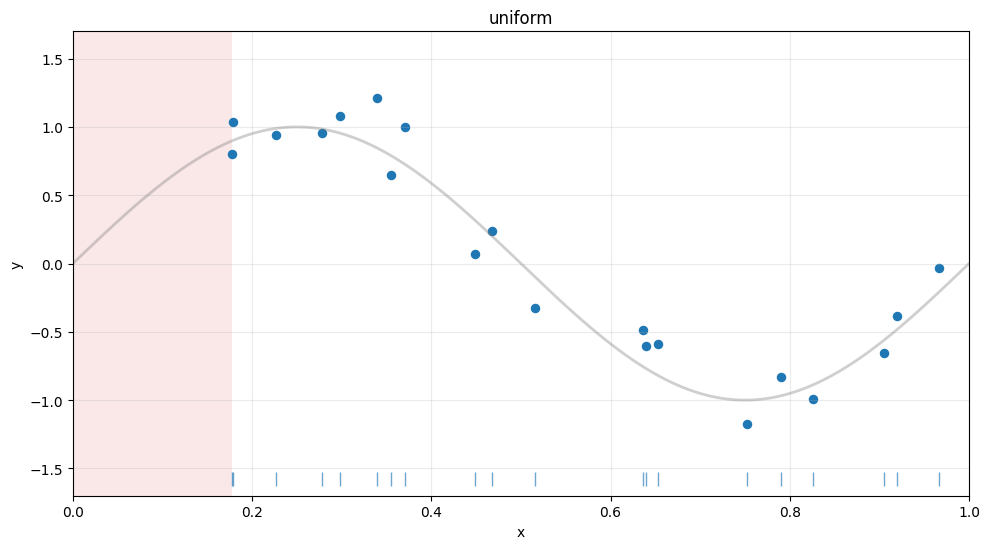

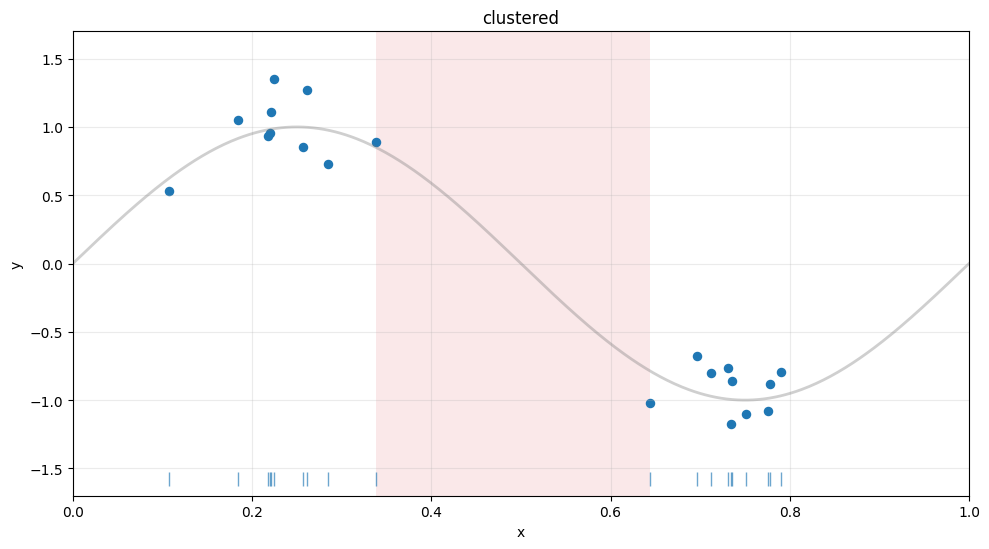

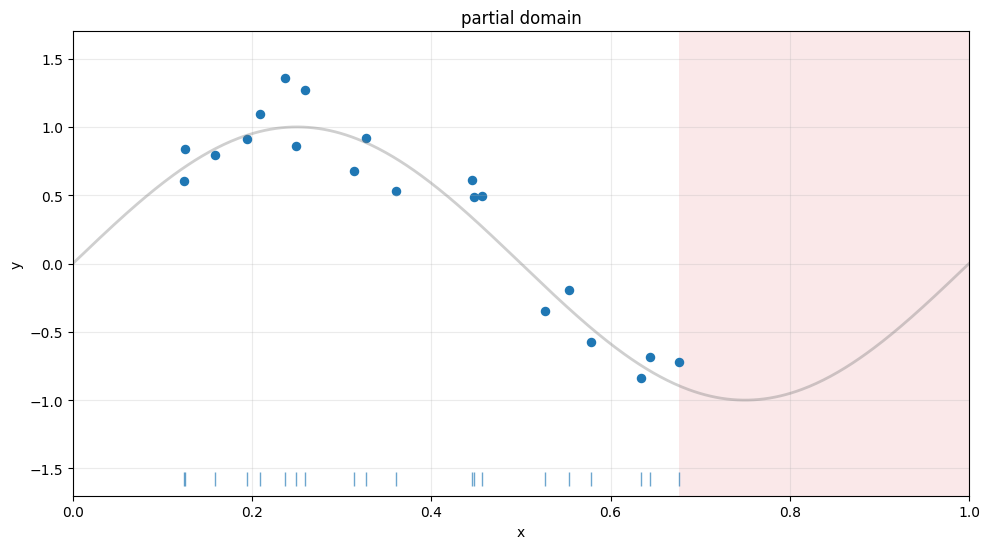

Data-space coverage summaries
01. case=uniform, n=20, x_min=0.1774, x_max=0.9670, largest_gap=0.1774, gap_start=0, gap_end=0.1774
02. case=clustered, n=20, x_min=0.1073, x_max=0.7904, largest_gap=0.3061, gap_start=0.3377, gap_end=0.6438
03. case=partial domain, n=20, x_min=0.1241, x_max=0.6769, largest_gap=0.3231, gap_start=0.6769, gap_end=1.0000


In [4]:
# Compare different ways of observing the same hidden function.
sampling_cases = [
    {"label": "uniform", "n": 20, "noise": 0.20, "sampling": "uniform", "seed": 2026},
    {"label": "clustered", "n": 20, "noise": 0.20, "sampling": "clustered", "seed": 2026},
    {"label": "partial domain", "n": 20, "noise": 0.20, "sampling": "partial_domain", "seed": 2026},
]

x_grid = data.make_test_grid(n_points=500)
coverage_rows = []

for settings in sampling_cases:
    x_case, y_case = data.make_regression_data(
        n=settings["n"],
        noise_std=settings["noise"],
        seed=settings["seed"],
        sampling=settings["sampling"],
    )
    gap_edges = np.r_[0.0, x_case, 1.0]
    gaps = np.diff(gap_edges)
    largest_gap_index = int(np.argmax(gaps))
    gap_start = gap_edges[largest_gap_index]
    gap_end = gap_edges[largest_gap_index + 1]
    coverage_rows.append(
        {
            "case": settings["label"],
            "n": len(x_case),
            "x_min": np.min(x_case),
            "x_max": np.max(x_case),
            "largest_gap": np.max(gaps),
            "gap_start": gap_start,
            "gap_end": gap_end,
        }
    )

    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.axvspan(gap_start, gap_end, color="#d62728", alpha=0.10, linewidth=0)
    ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0)
    ax.scatter(x_case, y_case, color="#1f77b4", s=34)
    ax.plot(x_case, np.full_like(x_case, -1.58), "|", color="#1f77b4", markersize=10, alpha=0.65)
    ax.set_title(settings["label"])
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.7, 1.7)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    show_fig(fig)

print_rows(coverage_rows, title="Data-space coverage summaries")


### After running: diagnose support, then transfer the idea

Read the panels as evidence maps.

- A dense region means nearby predictions may be better constrained.
- A gap means several different functions may still agree with the data while disagreeing between observations.
- A missing domain region means prediction becomes extrapolation.

**Repack.** Coverage is a data-space property. It determines where later model behaviour is supported by observations and where it must rely more heavily on assumptions.

### Transition: from one-dimensional coverage to data-space geometry

So far, coverage was visible because $x$ was one-dimensional. In higher-dimensional problems, coverage is harder to see. The next section is still a data-space question, not a new topic:

> Where does the finite evidence sit inside the space of possible observations?

## Transfer Intuition: Data-Space Geometry

Coverage becomes harder to see when $x$ has many dimensions. Counting rows is not enough; we also care about where those rows sit in the possible input space.

The one-dimensional regression example is deliberately simple because the rule is visible as a curve. A useful transfer intuition is a lower-dimensional manifold: a structured subset of a much larger possible space. In the square below, random points fill the whole two-dimensional space. Structured observations concentrate near a one-dimensional curve. Both panels have the same number of points, but they describe very different data spaces.

This is why high-dimensional data can still be learnable. An image represented by pixels lives in an enormous array space, but meaningful real-world images occupy a much more constrained subset. The learner does not need evidence for every possible array; it needs evidence that resolves the structured region relevant to the task.

If sampling your process produced pure noise, there would be little stable structure for a learner to exploit. Most real scientific and physical processes are not pure noise: conservation laws, biology, engineering constraints, human behaviour, measurement protocols, and selection effects all create structure. The data-space question is whether your collected observations cover the part of that structure where you want the model to work.

> **Discuss.** What is the constrained region or manifold-like structure in your data, and what would count as good coverage of it? What changed from the one-dimensional example, what stayed fixed, and why is the active lever still $\mathcal{D}$?

This is the fourth data-space diagnostic: geometry. The practical lesson is modest but important: data have geometry, and coverage of that geometry matters. Once we care about coverage, the next question is how to spend a limited observation budget.

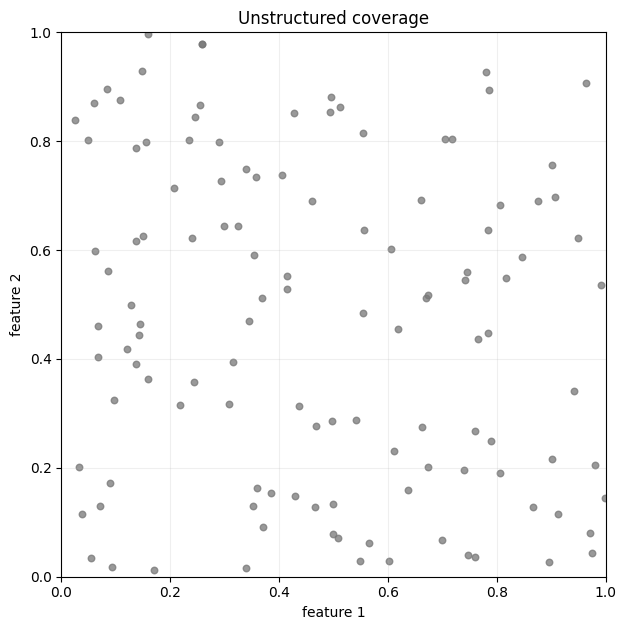

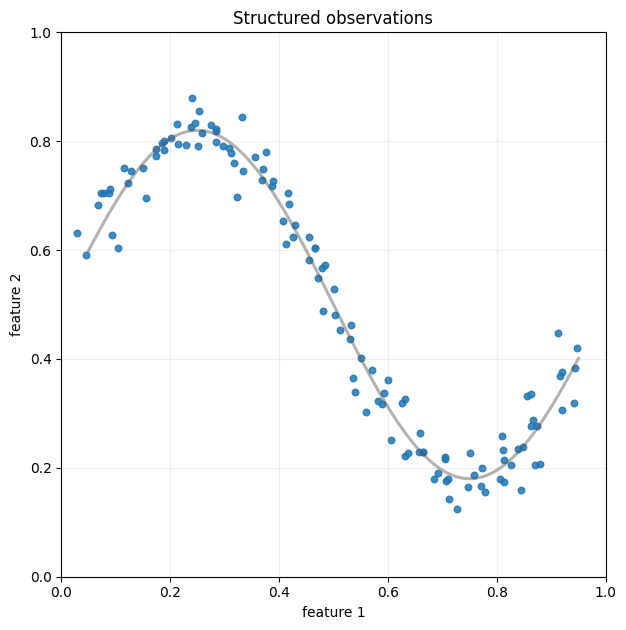

In [5]:
# A 2D sketch of unstructured samples versus samples near a lower-dimensional manifold.
rng = np.random.default_rng(11)
n_points = 120

random_points = rng.uniform(0.0, 1.0, size=(n_points, 2))

curve_t = np.linspace(0.05, 0.95, n_points)
curve_y = 0.50 + 0.32 * np.sin(2.0 * np.pi * curve_t)
structured_points = np.column_stack(
    [
        curve_t + rng.normal(0.0, 0.015, size=n_points),
        curve_y + rng.normal(0.0, 0.035, size=n_points),
    ]
)
structured_points = np.clip(structured_points, 0.0, 1.0)

space_views = [
    ("Unstructured coverage", random_points, None, "#777777", 0.75),
    ("Structured observations", structured_points, (curve_t, curve_y), "#1f77b4", 0.85),
]

for title, points, curve, color, alpha in space_views:
    fig, ax = plt.subplots(figsize=(7.0, 6.4))
    if curve is not None:
        ax.plot(curve[0], curve[1], color="#555555", alpha=0.45, linewidth=2.2)
    ax.scatter(points[:, 0], points[:, 1], s=22, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.grid(alpha=0.20)
    fig.tight_layout()
    show_fig(fig)


### After running: compare row count with geometry

Both panels contain the same number of points, but they describe different data spaces.

- Random points spread across the ambient box.
- Structured points concentrate near a lower-dimensional pattern.
- Equal row count does not imply equal support for the task-relevant region.

**Repack.** Data quantity is not the same as data support. A dataset can have many rows and still leave the relevant structure weakly covered.

## Coverage Versus Repeated Measurement

The geometry section asked where observations sit. The design question asks how those observations got allocated. With a fixed observation budget, we often trade coverage against repetition.

Sampling many distinct locations helps resolve the shape of the signal across the domain. Repeating observations at fewer locations helps estimate local variation and noise. In the observation model $y_i=f^*(x_i)+\epsilon_i$, repeated measurements at the same $x$ give direct evidence about the local mean and the spread of $\epsilon_i$ around that point. They can reduce uncertainty about function behaviour nearby, but they do less to resolve gaps elsewhere.

This is the fifth data-space diagnostic: design. Neither design is automatically better. The right choice depends on the scientific or decision question: do we need to map the function broadly, estimate uncertainty at a few critical settings, or improve evidence near a boundary where decisions are sensitive?

Before running the next cell, predict which design will have more unique $x$ values, which will give direct evidence about local noise, and which will leave fewer unsupported regions across the full domain.

> **Discuss.** In your own work, where would the next observation change the decision most: an under-sampled region, a high-stakes boundary, a repeated measurement at a noisy setting, or a subgroup whose behaviour you do not yet trust?

The next cell uses the same number of observations in two designs. One spreads observations across the domain. The other repeats measurements at a smaller number of locations.


### Before running: choose a measurement strategy

With a fixed observation budget, there is a trade-off. Predict what each design buys before looking at the plots.

| Strategy | What it helps estimate | What it may leave weak |
|---|---|---|
| Spread observations broadly | | |
| Repeat measurements at fewer locations | | |


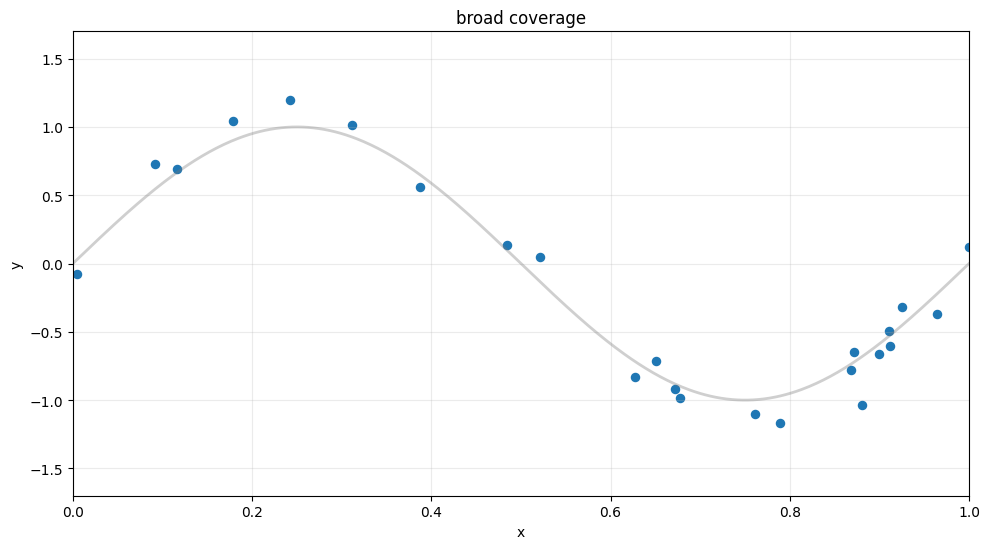

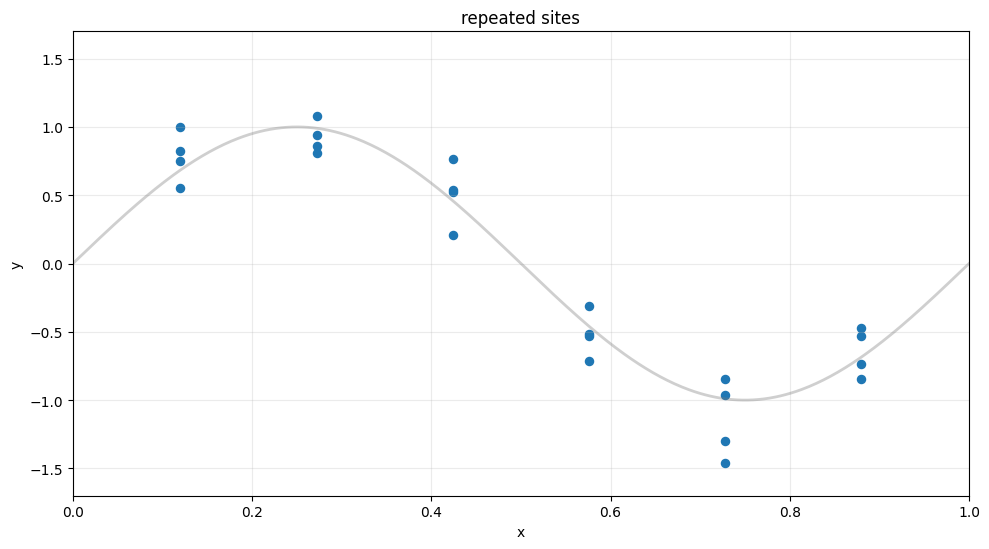

Fixed-budget design summaries
01. design=broad coverage, n=24, unique_x=24, largest_gap=0.1065, y_std=0.7298
02. design=repeated sites, n=24, unique_x=6, largest_gap=0.1520, y_std=0.8051

What repeated observations reveal locally
01. x=0.1200, n_repeats=4, local_mean_y=0.7813, local_sd_y=0.1855
02. x=0.2720, n_repeats=4, local_mean_y=0.9235, local_sd_y=0.1163
03. x=0.4240, n_repeats=4, local_mean_y=0.5086, local_sd_y=0.2298
04. x=0.5760, n_repeats=4, local_mean_y=-0.5184, local_sd_y=0.1649
05. x=0.7280, n_repeats=4, local_mean_y=-1.1422, local_sd_y=0.2834
06. x=0.8800, n_repeats=4, local_mean_y=-0.6450, local_sd_y=0.1743


In [6]:
# Compare two fixed-budget data designs: broad coverage versus repeated observations.
observation_budget = 24
noise_std_design = 0.18
rng = np.random.default_rng(34)

x_broad = np.sort(rng.uniform(0.0, 1.0, size=observation_budget))
y_broad = data.true_function(x_broad) + rng.normal(0.0, noise_std_design, size=observation_budget)

repeat_sites = np.linspace(0.12, 0.88, 6)
repeats_per_site = observation_budget // len(repeat_sites)
x_repeated = np.repeat(repeat_sites, repeats_per_site)
y_repeated = data.true_function(x_repeated) + rng.normal(0.0, noise_std_design, size=len(x_repeated))

designs = [
    ("broad coverage", x_broad, y_broad),
    ("repeated sites", x_repeated, y_repeated),
]

for label, x_design, y_design in designs:
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0)
    ax.scatter(x_design, y_design, color="#1f77b4", s=34)
    ax.set_title(label)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.7, 1.7)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    show_fig(fig)

summary_rows = []
for label, x_design, y_design in designs:
    gaps = np.diff(np.r_[0.0, np.unique(x_design), 1.0])
    summary_rows.append(
        {
            "design": label,
            "n": len(x_design),
            "unique_x": len(np.unique(x_design)),
            "largest_gap": np.max(gaps),
            "y_std": np.std(y_design),
        }
    )

print_rows(summary_rows, title="Fixed-budget design summaries")

repeat_rows = []
for x_site in repeat_sites:
    local_y = y_repeated[x_repeated == x_site]
    repeat_rows.append(
        {
            "x": x_site,
            "n_repeats": len(local_y),
            "local_mean_y": np.mean(local_y),
            "local_sd_y": np.std(local_y, ddof=1),
        }
    )

print()
print_rows(repeat_rows, title="What repeated observations reveal locally")


## Summary: What D Can and Cannot Decide

1. **Representation defines the rows.** Writing evidence as $(x_i,y_i)$ decides what the learner can see as input, what it must predict as output, and what gets left out as hidden context.

2. **Noise blurs the signal.** Observed responses may vary around the underlying process. In this simulation we can measure that variation against $f^*$; in real work we usually infer it indirectly.

3. **Coverage decides where evidence is local.** Clustered data may leave weakly covered regions between clusters. Partial-domain data can turn prediction on the right-hand side into extrapolation.

4. **Geometry decides what coverage means.** In one dimension we can inspect gaps directly. In high-dimensional settings, coverage usually needs proxies such as slices, neighbours, embeddings, subgroups, or deployment scenarios.

5. **Design allocates the observation budget.** Broad coverage constrains between-site behaviour. Repeated sites make local variation more visible. Neither is automatically better; the right design depends on the decision.

6. **Underdetermination remains.** Many hidden functions can agree with the observations we collected and disagree elsewhere. Later, the hypothesis space and objective will decide which extension is selected.

Use these synthesis prompts to connect the toy example to your own work:

> **Discuss.** What are $x$ and $y$ in your problem, and what is lost when the world is forced into that representation?

> **Discuss.** Which variation is signal, which variation is noise, and how would you know from the data alone?

> **Discuss.** What assumptions will the hypothesis space or objective have to add because the data do not decide the question by themselves?

First principle: learning begins with evidence. The data space defines what the learner actually gets to use. It is also an experimental-design question.


## Data-Space Diagnostic Checklist

Before choosing a model, use this checklist to summarize what $\mathcal{D}$ can and cannot decide.

| Diagnostic | Question | Modelling implication |
|---|---|---|
| Representation | What is one row, input, and response? | Defines what the learner can use and what is hidden. |
| Noise | How variable are repeated or nearby observations? | Limits confidence in fitted structure. |
| Coverage | Where is evidence dense, sparse, or missing? | Controls where predictions are locally supported. |
| Data-space geometry | What structured region of the possible input space matters? | Prevents row count from being mistaken for support. |
| Design | How were observations allocated? | Determines whether data reduce the uncertainty that matters. |
| Underdetermination | What remains compatible with the observations? | Explains why $\mathcal{H}$ and $\mathcal{O}$ are still needed. |

> **Synthesis task.** For your own dataset, identify one thing that changed during this notebook, one thing that stayed fixed, and the active lever in each section: $\mathcal{D}$, $\mathcal{H}$, or $\mathcal{O}$.

**Notebook takeaway.** $\mathcal{D}$ constrains possible explanations, but it does not select a final model by itself.

## Bridge to Notebook 02

This notebook did not try to choose a curve. It asked what the evidence $\mathcal{D}$ contains: how the problem was represented, where observations lie, where they are missing, how noisy they are, what geometry they cover, and which parts of the running problem remain underdetermined.

Notebook 02 keeps that same observation world but changes focus from evidence to possibility. Once $\mathcal{D}$ is fixed, the next modelling choice is $\mathcal{H}$: which functions are allowed to explain these rows at all?


## References

- Shalev-Shwartz, S., & Ben-David, S. (2014). [*Understanding Machine Learning: From Theory to Algorithms*](https://www.cambridge.org/core/books/understanding-machine-learning/3059695661405D25673058E43C8BE2A6). Formal language for data distributions, datasets, hypothesis classes, loss functions, and empirical risk minimisation.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). [*The Elements of Statistical Learning: Data Mining, Inference, and Prediction*](https://link.springer.com/book/10.1007/978-0-387-84858-7), 2nd ed. Supervised regression, model assessment, and train/test reasoning.
- Bengio, Y., Courville, A., & Vincent, P. (2013). [*Representation Learning: A Review and New Perspectives*](https://arxiv.org/abs/1206.5538), *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 35(8), 1798-1828. Manifold and representation-learning framing for high-dimensional data.
